## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

## 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)

In [6]:
df = pd.read_csv('data/golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

/var/folders/_5/c6lzttjj0cg6_d15t6wc96_r0000gn/T/ipykernel_65114/812006323.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outcome'] = df['cancer'].map(mapper)


,Samples,cancer,outcome
0,39,allB,0
1,40,allB,0
2,42,allB,0
3,47,allB,0
4,48,allB,0


In [7]:
target = df['outcome']
features = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'])

print(f'Observations: {features.shape[0]}')
print(f'Genes used as predictors: {features.shape[1]}')

Observations: 72
Genes used as predictors: 7129


## 2

In [8]:
ols_model = LinearRegression()
ols_model.fit(features, target)
ols_predictions = ols_model.predict(features)
ols_residuals = ols_predictions - target

print(f'OLS training MSE: {mse(target, ols_predictions):.6g}')

OLS training MSE: 3.42388e-30


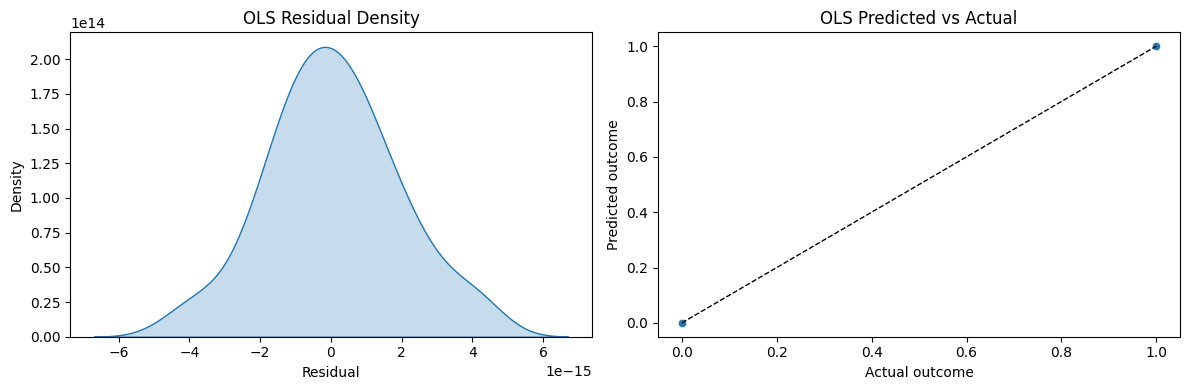

In [9]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

sns.kdeplot(ols_residuals, fill=True, ax=axes[0])
axes[0].set(title='OLS Residual Density', xlabel='Residual')

sns.scatterplot(x=target, y=ols_predictions, ax=axes[1])
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
axes[1].set(title='OLS Predicted vs Actual', xlabel='Actual outcome', ylabel='Predicted outcome')

plt.tight_layout()
plt.show()

The training MSE is basically zero, so the linear model is interpolating the training data almost perfectly. That makes sense here since the dataset has way more gene predictors than patient observations, which gives an unregularized linear model enough flexibility to just memorize the sample.

## 3

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=100)
neg_cv_scores = cross_val_score(
    estimator=LinearRegression(),
    X=features,
    y=target,
    scoring='neg_mean_squared_error',
    cv=kf,
)
fold_mse = -neg_cv_scores

print('Fold MSE values:', fold_mse)
print(f'Mean CV MSE: {fold_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(fold_mse):.6f}')
print(f'Standard deviation: {fold_mse.std():.6f}')

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


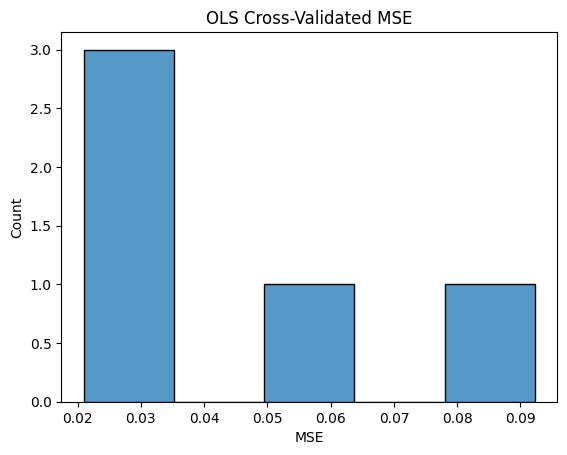

In [11]:
ax = sns.histplot(x=fold_mse, bins=5)
ax.set_xlabel('MSE')
ax.set_title('OLS Cross-Validated MSE')
plt.show()

The gap between near-zero training error and a much bigger cross-validated MSE is a classic high-variance pattern. OLS has very low bias on the training sample, but it's unstable out of sample because it's trying to fit thousands of genes with only 72 patients. Cross validation shows that the apparent perfect fit doesn't generalize nearly as well as the training error makes it look.

## 4

In [13]:
std_scaler = StandardScaler()
features_sc = std_scaler.fit_transform(features)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(alphas=alpha_grid, cv=10, max_iter=10000, random_state=100)
lasso_cv.fit(features_sc, target)

best_alpha = lasso_cv.alpha_
path_mean_mse = lasso_cv.mse_path_.mean(axis=1)
best_idx = np.argmin(path_mean_mse)

coef_path = []
for a in lasso_cv.alphas_:
    fit = Lasso(alpha=a, max_iter=10000).fit(features_sc, target)
    coef_path.append(fit.coef_)
coef_path = np.array(coef_path)

best_coefs = coef_path[best_idx]
keep_idx = np.nonzero(best_coefs)[0]
selected_genes = features.columns[keep_idx].tolist()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000).fit(features_sc, target)
lasso_predictions = lasso_best.predict(features_sc)

print(f'Optimal alpha: {best_alpha:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {features.shape[1] - len(selected_genes)}')
selected_genes

Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059


['AF000560_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L13278_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27819_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M34344_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'U37055_rna1_s_at',
 'X07438_s_at',
 'M13690_s_at',
 'M26708_s_at',
 'M84371_rna1_s_at',
 'X12876_s_at',
 'U26312_s_at',
 'X85116_rna1_s_at',

The LASSO kept 80 genes and discarded 7,049 genes from the original 7,129 predictors. The selected genes are:

AF000560_at, AF002020_at, AF006087_at, D26579_at, D29956_at, D42043_at, D50840_at, D86982_at, HG2161-HT2231_at, J04101_at, J04164_at, L12723_at, L13848_at, L20941_at, M12759_at, M17754_at, M19507_at, M20902_at, M22960_at, M23197_at, M27891_at, M28713_at, M31994_at, M63138_at, M84526_at, M95178_at, M96326_rna1_at, M98539_at, U10868_at, U14588_at, U30828_at, U34877_at, U36621_cds2_at, U46751_at, U50136_rna1_at, U51127_at, U60062_at, U82313_at, U82759_at, U88666_at, U89942_at, X04143_at, X14789_at, X16706_at, X53331_at, X56741_at, X63753_at, X66533_at, X66867_cds1_at, X69111_at, X81479_at, X83378_at, X95735_at, X96698_at, Y00636_at, Y07604_at, Y07755_at, Y10207_at, Y12670_at, M96843_at, X58072_at, AC002477_s_at, L15326_s_at, X57351_at, K02777_s_at, U37055_rna1_s_at, U59632_s_at, X07438_s_at, M12959_s_at, M13690_s_at, M26708_s_at, M84371_rna1_s_at, X12876_s_at, M31211_s_at, U26312_s_at, X85116_rna1_s_at, HG4518-HT4921_r_at, L08010_at, U84388_at, X06318_at.

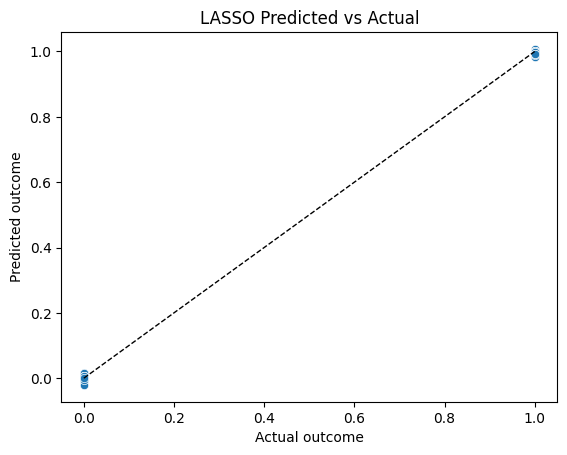

LASSO training MSE: 4.64279e-05


In [14]:
ax = sns.scatterplot(x=target, y=lasso_predictions)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Actual outcome', ylabel='Predicted outcome', title='LASSO Predicted vs Actual')
plt.show()

print(f'LASSO training MSE: {mse(target, lasso_predictions):.6g}')

## 5

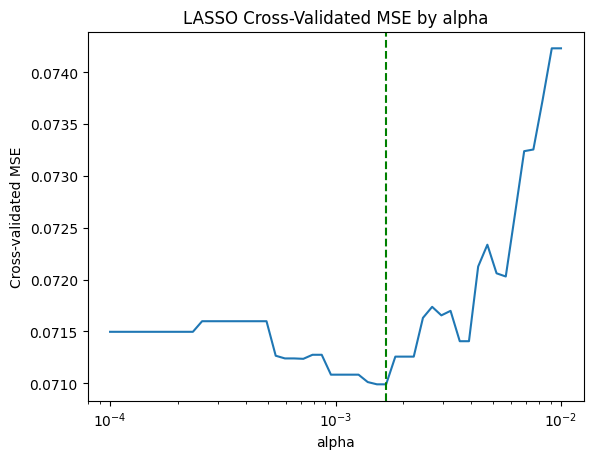

In [15]:
ax = sns.lineplot(x=lasso_cv.alphas_, y=path_mean_mse)
ax.axvline(x=best_alpha, color='green', linestyle='--', linewidth=1.5)
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='Cross-validated MSE', title='LASSO Cross-Validated MSE by alpha')
plt.show()

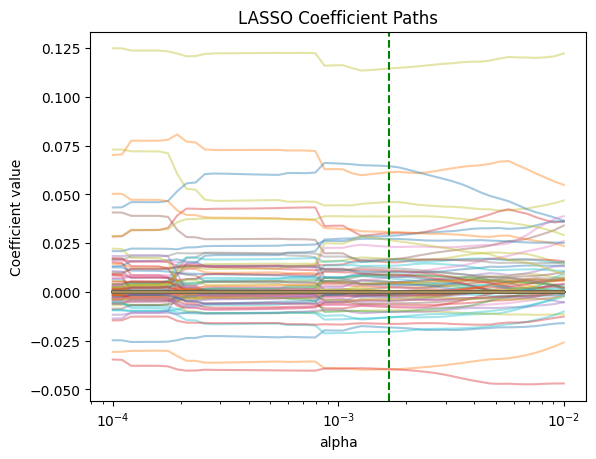

In [16]:
fig, ax = plt.subplots()
for j in range(coef_path.shape[1]):
    ax.plot(lasso_cv.alphas_, coef_path[:, j], alpha=0.4)
ax.axvline(x=best_alpha, linestyle='--', color='green')
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='Coefficient value', title='LASSO Coefficient Paths')
plt.show()

Large alpha values on the left side of the plot apply too much shrinkage, so the model underfits there. Really small values on the right side let too many coefficients back into the model, so that end is where overfitting kicks in. The minimum expected error lands at roughly alpha = 0.0006551286.

## 6

OLS does the training set perfectly because this is a high-dimensional setup with way more predictors than observations, so the model can basically memorize the sample. That flexibility pushes training error to zero, but it also makes the fitted coefficients really sensitive to noise.
LASSO does better predictively by shrinking coefficients and zeroing a lot of them out entirely. That bumps up bias a bit, but it cuts variance way down. In this dataset that trade-off pays off, since only a relatively small subset of genes seems to carry most of the signal for separating ALL from AML.

## 7

Humans have somewhere between 22,000 and 25,000 genes, and on top of that those genes interact in complicated ways to produce actual people. Once your feature space includes all the two-way and three-way and multi-way interactions, it can blow up really fast into something bigger than any high-quality genomics dataset out there. In situations like that, methods like LASSO let us narrow things down to a smaller subset of genes and interactions, which is way more workable for medical testing and genetics research.

## 8

These predictions are really just predictions. We don't have any causal identification of what happens when one gene or another takes a different value. The genes we observe are a tangled mix of simultaneously determined values, and we can't experimentally "flip" them without totally changing the organism. So the genes we end up selecting might be highly predictive without actually sitting on a causal pathway. Since we're only seeing correlation and not causation, we'd want to be cautious about jumping to surgical or pharmaceutical interventions that could harm or alter a patient's health and body.